<a href="https://colab.research.google.com/github/malith001/ME421_Mechanical_Systems_Lab-A04/blob/main/Control/E20389_Control.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Control

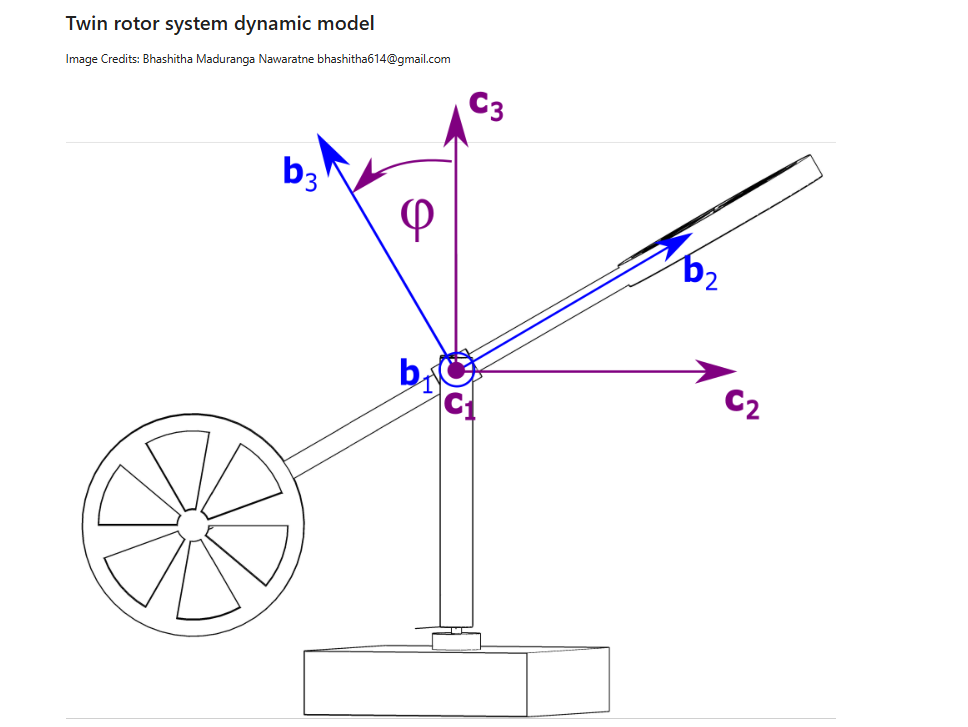

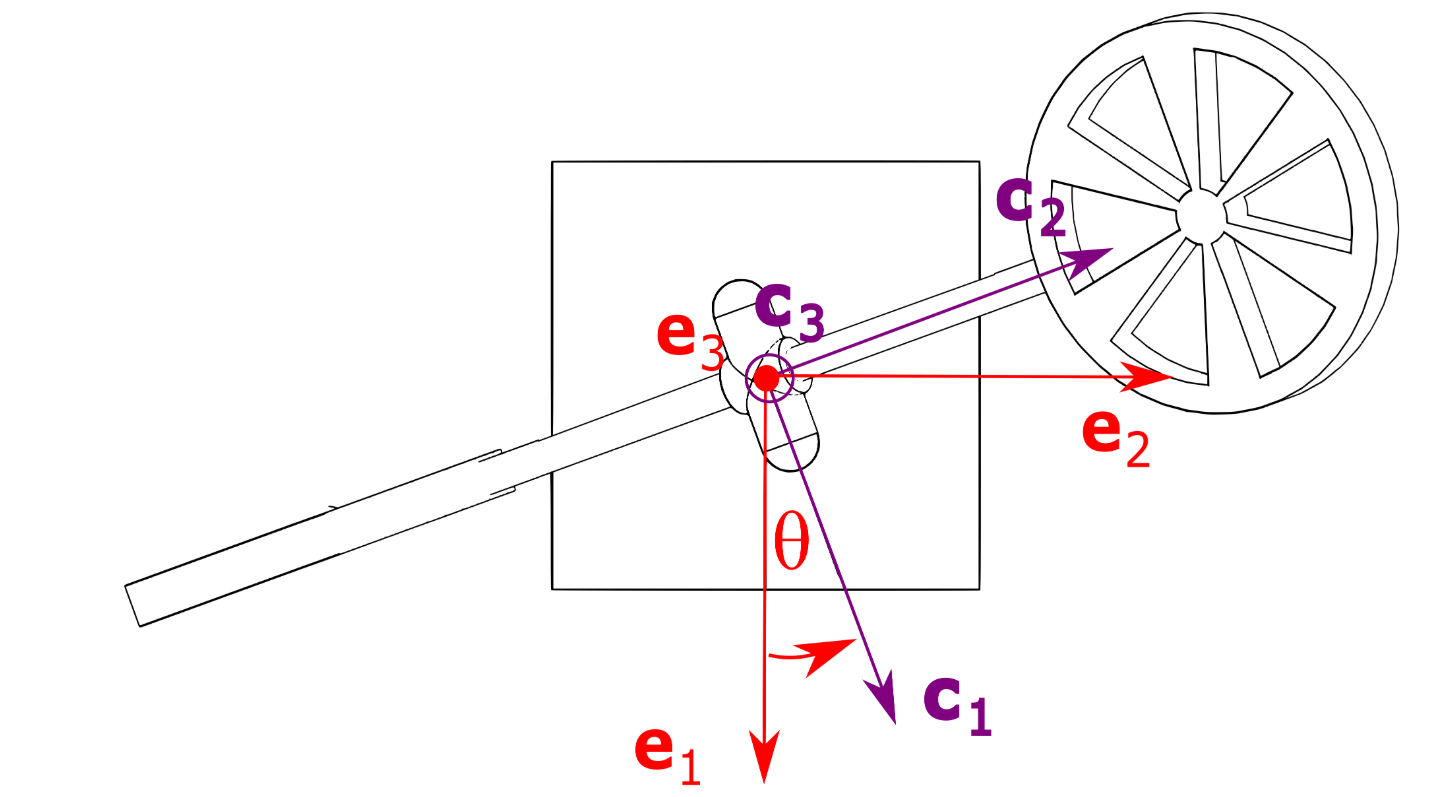

### Task #1: Twin Rotor System Dynamic Model

### Coordinate Transformations
Let the Earth frame be denoted as $e$ and another frame as $c$. The origins of both frames coincide, and their vertical axes ($e_3$ and $c_3$) also coincide.

The coordinate transformation from the Earth frame $e$ to frame $c$ is a rotation about the vertical 3-axis by an angle $\theta$. This is expressed as:

$$c = e R_{3} (\theta)$$

Where the rotation matrix $R_{3} (\theta)$ is defined as:

$$R_{3} (\theta)= \begin{bmatrix} \cos\theta & -\sin\theta & 0 \\ \sin\theta & \cos\theta & 0 \\ 0 & 0 & 1 \end{bmatrix}$$

Next, we define the body frame $b$ relative to frame $c$. The origins of both frames coincide, and their 1-axes ($b_1$ and $c_1$) also coincide.**Note that the axis b2 runs along the length of the rotor arm.**

The coordinate transformation from frame $c$ to the body frame $b$ is a rotation about the 1-axis by an angle $\phi$. This is expressed as:

$$b = c R_{1, \phi}$$

Where the fundamental rotation matrix for the 1-axis, $R_{1, \phi}$, is defined as:

$$R_{1, \phi} = \begin{bmatrix} 1 & 0 & 0 \\ 0 & \cos\phi & -\sin\phi \\ 0 & \sin\phi & \cos\phi \end{bmatrix}$$

### Combined Rotation Matrix

Now, we can find the total coordinate transformation from the Earth frame $e$ directly to the body frame $b$ by combining our two previous transformations.

Given:
1. $c = e R_{3, \theta}$
2. $b = c R_{1, \phi}$

We can substitute $c$ into the second equation to get the direct relationship:
$$b = e (R_{3, \theta} R_{1, \phi})$$

Let the combined rotation matrix be $R_{total} = R_{3, \theta} R_{1, \phi}$. We compute this by multiplying the two matrices:

$$R_{total} = R = \begin{bmatrix} \cos\theta & -\sin\theta & 0 \\ \sin\theta & \cos\theta & 0 \\ 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} 1 & 0 & 0 \\ 0 & \cos\phi & -\sin\phi \\ 0 & \sin\phi & \cos\phi \end{bmatrix}$$

Performing the matrix multiplication gives the final combined rotation matrix:

$$R = \begin{bmatrix}
\cos\theta & -\sin\theta\cos\phi & \sin\theta\sin\phi \\
\sin\theta & \cos\theta\cos\phi & -\cos\theta\sin\phi \\
0 & \sin\phi & \cos\phi
\end{bmatrix}$$

Therefore, the full coordinate transformation from the Earth frame to the body frame is:
$$b = e R $$

### Derivation of Angular Velocity

To find the angular velocity of the body frame relative to the Earth frame, we start with the time derivative of the combined rotation matrix $R = R_{3,\theta} R_{1,\phi}$. Applying the product rule for differentiation gives:

$$\dot{R} = \dot{R}_{3,\theta} R_{1,\phi} + R_{3,\theta} \dot{R}_{1,\phi}$$

In rigid body kinematics, the relationship between the time derivative of the rotation matrix $\dot{R}$ and the skew-symmetric angular velocity matrix $\hat{\Omega}$ in the body frame is given by $\dot{R} = R \hat{\Omega}$. Isolating $\hat{\Omega}$ yields:

$$\hat{\Omega} = R^T \dot{R}$$

Substituting $R^T = (R_{3,\theta} R_{1,\phi})^T = R_{1,\phi}^T R_{3,\theta}^T$ and our expression for $\dot{R}$:

$$\hat{\Omega} = (R_{1,\phi}^T R_{3,\theta}^T)(\dot{R}_{3,\theta} R_{1,\phi} + R_{3,\theta} \dot{R}_{1,\phi})$$
$$\hat{\Omega} = R_{1,\phi}^T (R_{3,\theta}^T \dot{R}_{3,\theta}) R_{1,\phi} + R_{1,\phi}^T (R_{3,\theta}^T R_{3,\theta}) \dot{R}_{1,\phi}$$

Since $R_{3,\theta}$ is an orthogonal matrix, $R_{3,\theta}^T R_{3,\theta} = I$ (the identity matrix), simplifying the second term:

$$\hat{\Omega} = R_{1,\phi}^T (R_{3,\theta}^T \dot{R}_{3,\theta}) R_{1,\phi} + R_{1,\phi}^T \dot{R}_{1,\phi}$$

Here, the terms $R_{3,\theta}^T \dot{R}_{3,\theta}$ and $R_{1,\phi}^T \dot{R}_{1,\phi}$ represent the skew-symmetric matrices for the rotation rates mapped to their specific physical axes:

1. **For the 3-axis (rotation of frame $c$ relative to $e$):**
This rotation happens about the $c_3$ axis (which coincides with $e_3$).
$$R_{3,\theta}^T \dot{R}_{3,\theta} = \begin{bmatrix} 0 & -\dot{\theta} & 0 \\ \dot{\theta} & 0 & 0 \\ 0 & 0 & 0 \end{bmatrix} = \dot{\theta}\hat{c}_3$$

2. **For the 1-axis (rotation of frame $b$ relative to $c$):**
This rotation happens about the $c_1$ axis (which coincides with $b_1$).
$$R_{1,\phi}^T \dot{R}_{1,\phi} = \begin{bmatrix} 0 & 0 & 0 \\ 0 & 0 & -\dot{\phi} \\ 0 & \dot{\phi} & 0 \end{bmatrix} = \dot{\phi}\hat{c}_1$$

Substituting these matrices back into the $\hat{\Omega}$ equation:

$$\hat{\Omega} = \begin{bmatrix} 1 & 0 & 0 \\ 0 & \cos\phi & \sin\phi \\ 0 & -\sin\phi & \cos\phi \end{bmatrix} \begin{bmatrix} 0 & -\dot{\theta} & 0 \\ \dot{\theta} & 0 & 0 \\ 0 & 0 & 0 \end{bmatrix} \begin{bmatrix} 1 & 0 & 0 \\ 0 & \cos\phi & -\sin\phi \\ 0 & \sin\phi & \cos\phi \end{bmatrix} + \begin{bmatrix} 0 & 0 & 0 \\ 0 & 0 & -\dot{\phi} \\ 0 & \dot{\phi} & 0 \end{bmatrix}$$

First, computing the matrix multiplication $R_{1,\phi}^T (\dot{\theta}\hat{c}_3) R_{1,\phi}$:

$$R_{1,\phi}^T (\dot{\theta}\hat{c}_3) R_{1,\phi} = \begin{bmatrix} 0 & -\dot{\theta}\cos\phi & \dot{\theta}\sin\phi \\ \dot{\theta}\cos\phi & 0 & 0 \\ -\dot{\theta}\sin\phi & 0 & 0 \end{bmatrix}$$

Finally, adding the $\dot{\phi}\hat{c}_1$ term:

$$\hat{\Omega} = \begin{bmatrix} 0 & -\dot{\theta}\cos\phi & \dot{\theta}\sin\phi \\ \dot{\theta}\cos\phi & 0 & 0 \\ -\dot{\theta}\sin\phi & 0 & 0 \end{bmatrix} + \begin{bmatrix} 0 & 0 & 0 \\ 0 & 0 & -\dot{\phi} \\ 0 & \dot{\phi} & 0 \end{bmatrix}$$

$$\hat{\Omega} = \begin{bmatrix} 0 & -\dot{\theta}\cos\phi & \dot{\theta}\sin\phi \\ \dot{\theta}\cos\phi & 0 & -\dot{\phi} \\ -\dot{\theta}\sin\phi & \dot{\phi} & 0 \end{bmatrix}$$

From this skew-symmetric matrix $\hat{\Omega}$, we extract the angular velocity vector $\Omega$ in the body frame $b$:

$$\Omega = \begin{bmatrix} \dot{\phi} \\ \dot{\theta}\sin\phi \\ \dot{\theta}\cos\phi \end{bmatrix}$$

### Angular Momentum in the Earth Frame

To find the angular momentum in the Earth frame (denoted as $\pi$), we first define the angular momentum in the body frame (denoted as $\Pi$).



Assuming the body axes align with the principal axes of inertia of the twin-rotor system, the inertia tensor $\mathbb{I}$ in the body frame is a diagonal matrix:

$$\mathbb{I} = \begin{bmatrix} I_1 & 0 & 0 \\ 0 & I_2 & 0 \\ 0 & 0 & I_3 \end{bmatrix}$$

The angular momentum in the body frame $\Pi$ is the product of the inertia tensor and the body frame angular velocity $\Omega$:

$$\Pi = \mathbb{I} \Omega = \begin{bmatrix} I_1 & 0 & 0 \\ 0 & I_2 & 0 \\ 0 & 0 & I_3 \end{bmatrix} \begin{bmatrix} \dot{\phi} \\ \dot{\theta}\sin\phi \\ \dot{\theta}\cos\phi \end{bmatrix} = \begin{bmatrix} I_1 \dot{\phi} \\ I_2 \dot{\theta}\sin\phi \\ I_3 \dot{\theta}\cos\phi \end{bmatrix}$$

Since a vector represented in the body frame is mapped to the Earth frame by pre-multiplying it by the rotation matrix $R$ (from our basis relationship $b = eR$), the spatial angular momentum in the Earth frame $\pi$ is given by:

$$\pi = R \mathbb{I} \Omega$$
$$\pi = R \Pi$$

Substituting the previously derived expressions for $R$ and $\Pi$:

$$\pi = \begin{bmatrix}
\cos\theta & -\sin\theta\cos\phi & \sin\theta\sin\phi \\
\sin\theta & \cos\theta\cos\phi & -\cos\theta\sin\phi \\
0 & \sin\phi & \cos\phi
\end{bmatrix} \begin{bmatrix} I_1 \dot{\phi} \\ I_2 \dot{\theta}\sin\phi \\ I_3 \dot{\theta}\cos\phi \end{bmatrix}$$

Expanding this matrix multiplication yields the explicit components of the angular momentum vector in the Earth frame:

$$\pi = \begin{bmatrix}
(I_1 \dot{\phi})\cos\theta - (I_2 \dot{\theta}\sin\phi)\sin\theta\cos\phi + (I_3 \dot{\theta}\cos\phi)\sin\theta\sin\phi \\
(I_1 \dot{\phi})\sin\theta + (I_2 \dot{\theta}\sin\phi)\cos\theta\cos\phi - (I_3 \dot{\theta}\cos\phi)\cos\theta\sin\phi \\
(I_2 \dot{\theta}\sin\phi)\sin\phi + (I_3 \dot{\theta}\cos\phi)\cos\phi
\end{bmatrix}$$

This can be simplified slightly by grouping terms, particularly in the third component:

$$\pi = \begin{bmatrix}
I_1 \dot{\phi}\cos\theta - (I_2 - I_3)\dot{\theta}\sin\theta\sin\phi\cos\phi \\
I_1 \dot{\phi}\sin\theta + (I_2 - I_3)\dot{\theta}\cos\theta\sin\phi\cos\phi \\
\dot{\theta}(I_2 \sin^2\phi + I_3 \cos^2\phi)
\end{bmatrix}$$

### Reactive Torque in the Earth Frame

The only external torque acting on the system is the reactive torque holding the rotor arm from roll motion. This torque acts strictly along the 2-axis in the body frame ($b_2$). Let's denote the magnitude of this torque as $T_2$.

The mechanical constraint torque vector in the body frame, $\tau_e$, is therefore defined as:

$$\tau_e = \begin{bmatrix} 0 \\ T_2 \\ 0 \end{bmatrix}$$

To map this reactive torque into the Earth frame (denoted as $T_e$), we pre-multiply the body torque vector by our combined coordinate transformation matrix $R$:

$$T_e = R \tau_e$$

Substituting our previously derived matrix $R$:

$$T_e = \begin{bmatrix}
\cos\theta & -\sin\theta\cos\phi & \sin\theta\sin\phi \\
\sin\theta & \cos\theta\cos\phi & -\cos\theta\sin\phi \\
0 & \sin\phi & \cos\phi
\end{bmatrix} \begin{bmatrix} 0 \\ T_2 \\ 0 \end{bmatrix}$$

Performing the matrix multiplication isolates the middle column, giving the exact components of the reactive torque in the Earth frame:

$$T_e = \begin{bmatrix}
-T_2\sin\theta\cos\phi \\
T_2\cos\theta\cos\phi \\
T_2\sin\phi
\end{bmatrix}$$

### Control Torque in the Body Frame

The control torques are generated by the thrust from the air on the two rotor blades. Let the torque magnitudes from rotor 1 and rotor 2 be $u_1$ and $u_2$, respectively.

The normal of the rotation plane for rotor 1 makes an angle $\alpha$ with the $b_1$ axis, and the normal for rotor 2 makes an angle $\beta$ with the $b_1$ axis. Assuming the rotors act purely in the $b_1$-$b_3$ plane, we can project these torques onto the body axes using trigonometric decomposition.

The control torque vector in the body frame, denoted as $\tau_u$, can be expressed in matrix form as:

$$\tau_u = \begin{bmatrix} 1 & 0 \\ 0 & 0 \\ 0 & 1 \end{bmatrix} \begin{bmatrix} \cos\alpha & -\cos\beta \\ \sin\alpha & -\sin\beta \end{bmatrix} \begin{bmatrix} u_1 \\ u_2 \end{bmatrix}$$

Expanding this matrix multiplication gives the explicit components of the control torque along the body axes:

$$\tau_b^u = \begin{bmatrix} 1 & 0 \\ 0 & 0 \\ 0 & 1 \end{bmatrix} \begin{bmatrix} u_1\cos\alpha - u_2\cos\beta \\ u_1\sin\alpha - u_2\sin\beta \end{bmatrix} = \begin{bmatrix} u_1\cos\alpha - u_2\cos\beta \\ 0 \\ u_1\sin\alpha - u_2\sin\beta \end{bmatrix}$$

To use this in the full spatial equations of motion, this body-frame torque must be mapped to the Earth frame (denoted as $T_u$) by pre-multiplying by the coordinate transformation matrix $R$:

$$T_u = R \tau_u = R \begin{bmatrix} 1 & 0 \\ 0 & 0 \\ 0 & 1 \end{bmatrix} \begin{bmatrix} \cos\alpha & -\cos\beta \\ \sin\alpha & -\sin\beta \end{bmatrix} \begin{bmatrix} u_1 \\ u_2 \end{bmatrix}$$